In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd

In [3]:
from datetime import datetime, timedelta

In [4]:
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

In [5]:
from skforecast.plot import calculate_lag_autocorrelation

In [29]:
"""
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import plot_residuals
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})
"""

'\nimport matplotlib.pyplot as plt\nfrom statsmodels.graphics.tsaplots import plot_acf, plot_pacf\nfrom skforecast.plot import plot_residuals\nimport plotly.graph_objects as go\nimport plotly.io as pio\nimport plotly.offline as poff\npio.templates.default = "seaborn"\npoff.init_notebook_mode(connected=True)\nplt.style.use(\'seaborn-v0_8-darkgrid\')\nplt.rcParams.update({\'font.size\': 8})\n'

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [7]:
#df = pd.read_csv("../data/raw/tempload.csv", index_col = "date", parse_dates = True)
#need to drop duplicates
#idk why the extract script is buggy
#chain it all togther
# df isn't defined yet in the df["date"] call so we need to use pipe
df = (pd.read_csv("../data/raw/tempload.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [8]:
# check that the index is complete
start_date = df.index.min()
end_date = df.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=df.index.freq)
is_index_complete = (df.index == complete_date_range).all()
print(f"Index complete: {is_index_complete}")
print(f"Number of rows with missing values: {df.isnull().any(axis=1).mean()}")

Index complete: True
Number of rows with missing values: 0.0009504257907542579


In [7]:
#check for rows with missing values
df[df.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,
2024-02-20 07:00:00,NaN,3.061500,0
2024-02-20 08:00:00,NaN,2.061500,0
2024-02-20 09:00:00,NaN,1.811500,0
2024-02-20 10:00:00,NaN,1.161500,0
2024-02-20 11:00:00,NaN,1.061500,0
2024-02-20 12:00:00,NaN,0.611500,0
2024-02-20 13:00:00,NaN,-0.288500,0
2024-02-20 14:00:00,NaN,1.011500,1
2024-02-20 15:00:00,NaN,5.011500,1


<Axes: xlabel='date'>

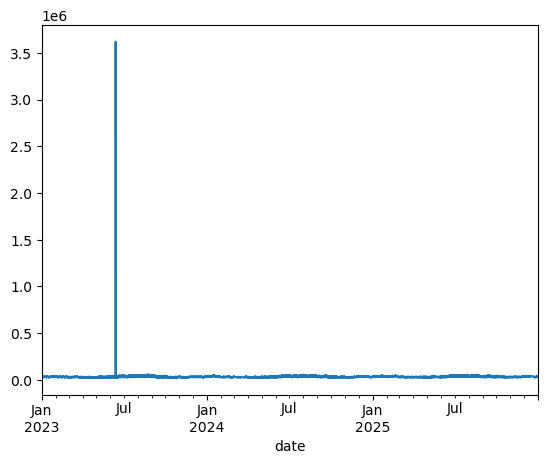

In [9]:
df.Demand.plot()

In [10]:
#clearly there is an error the the data collection that we need to replace
df["Demand"] = (df["Demand"]
    .mask(df["Demand"] == df["Demand"].max())
    .interpolate(method="time")
)

<Axes: xlabel='date'>

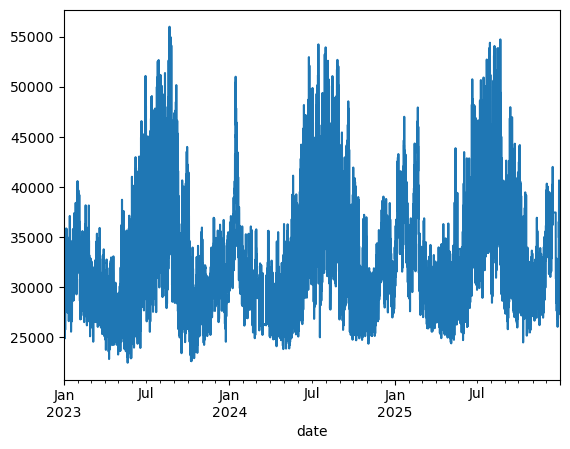

In [11]:
df.Demand.plot()

In [16]:
# Reshape data into hour x date matrix
heatmap_data = df.copy()
heatmap_data["date_only"] = heatmap_data.index.date
heatmap_data["hour"] = heatmap_data.index.hour

pivot = heatmap_data.pivot(index="date_only", columns="hour", values="Demand")

In [20]:
pivot.index

Index([2023-01-01, 2023-01-02, 2023-01-03, 2023-01-04, 2023-01-05, 2023-01-06,
       2023-01-07, 2023-01-08, 2023-01-09, 2023-01-10,
       ...
       2025-12-22, 2025-12-23, 2025-12-24, 2025-12-25, 2025-12-26, 2025-12-27,
       2025-12-28, 2025-12-29, 2025-12-30, 2025-12-31],
      dtype='object', name='date_only', length=1096)

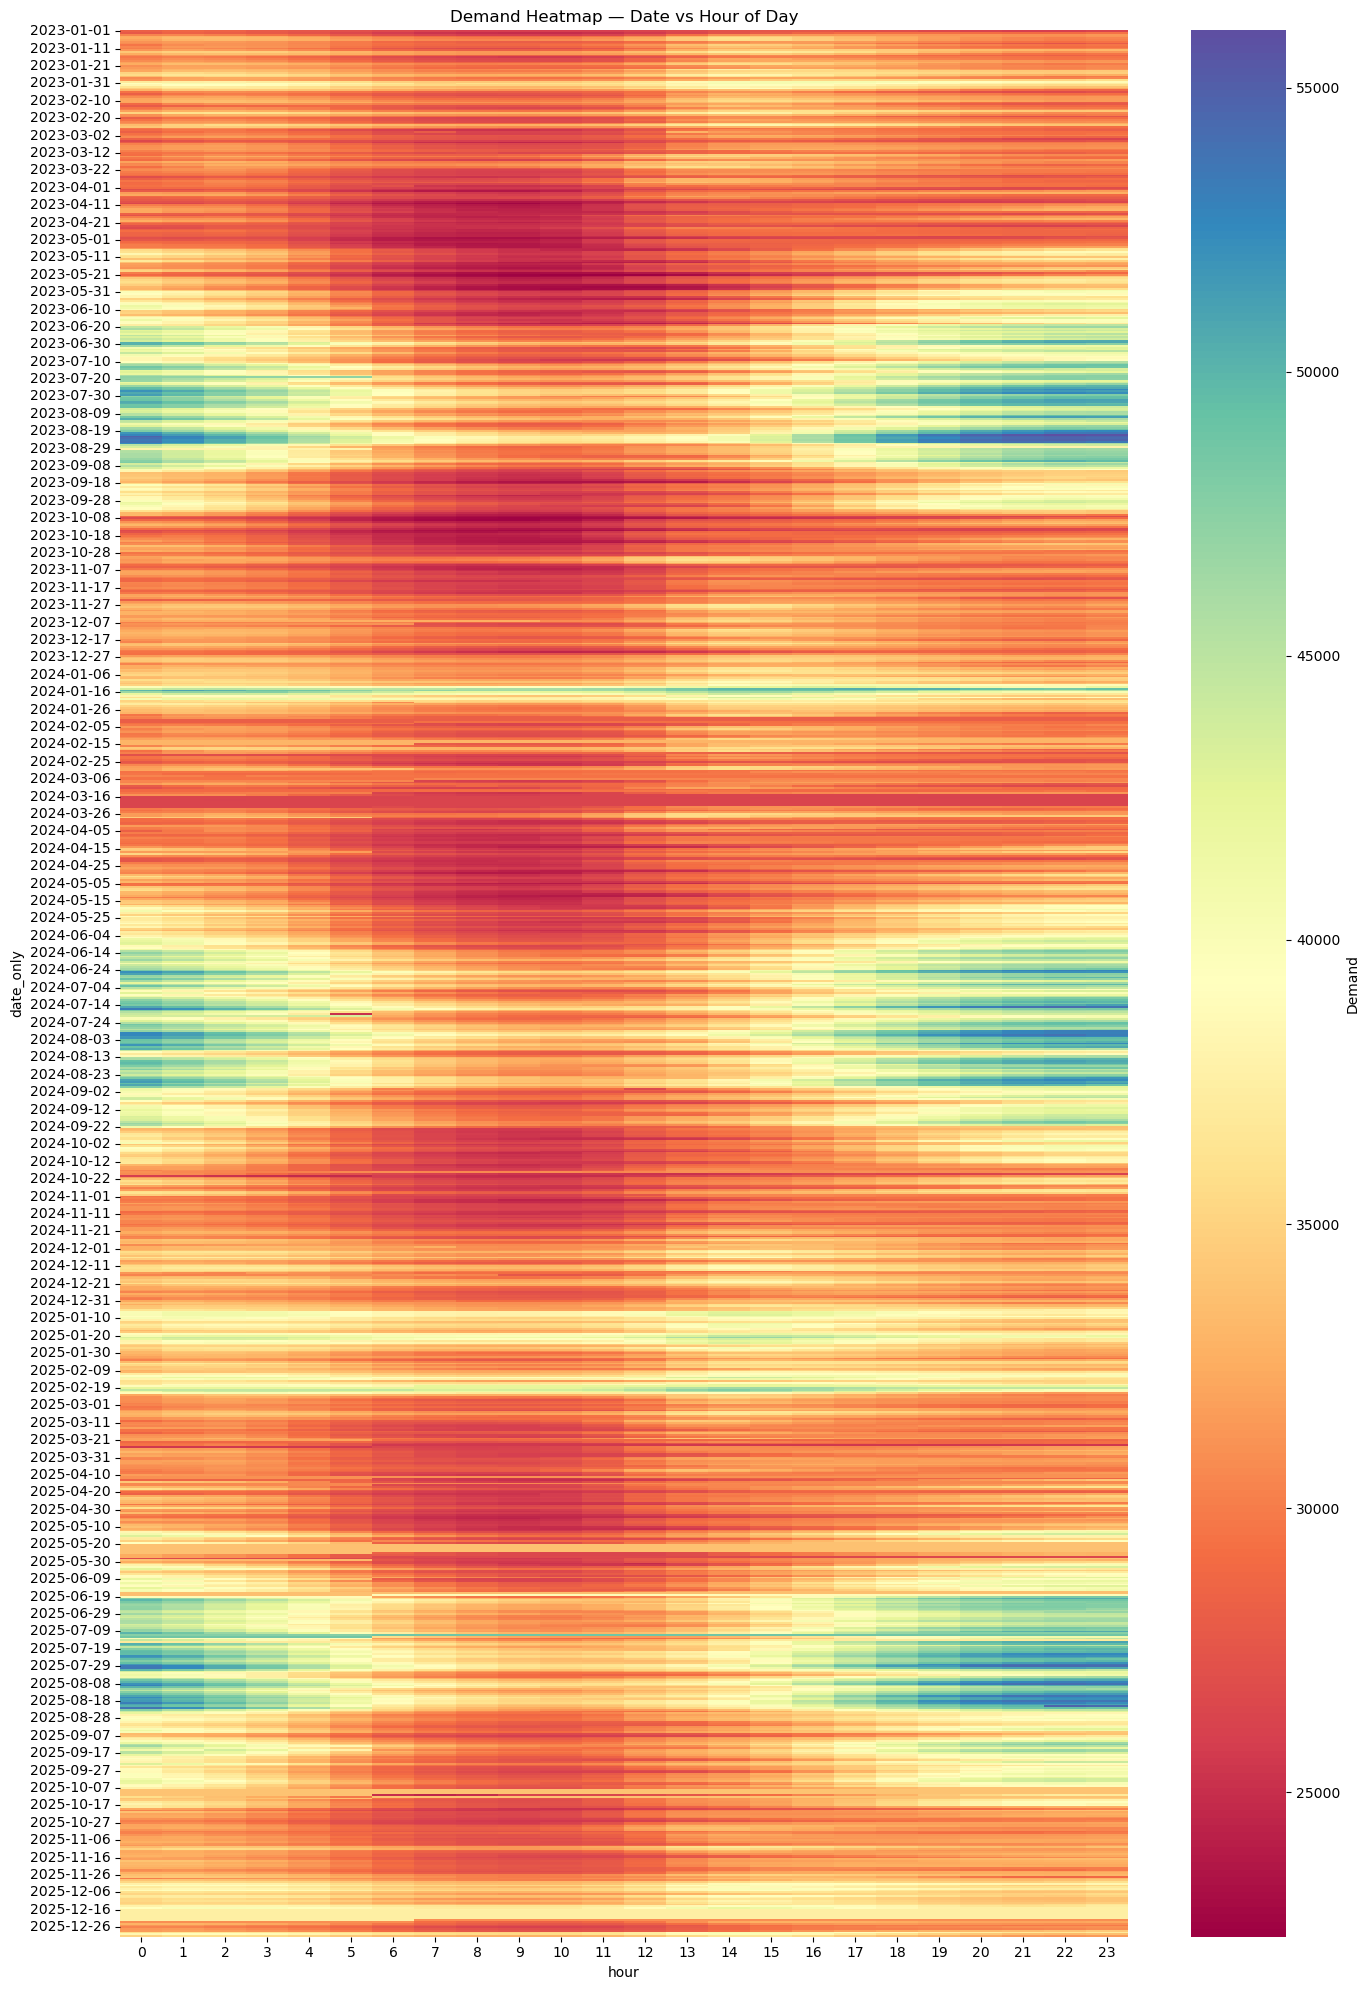

In [21]:
fig, ax = plt.subplots(figsize=(14, 20))
sns.heatmap(pivot, cmap="Spectral", ax=ax, cbar_kws={"label": "Demand"})
ax.set_title("Demand Heatmap — Date vs Hour of Day")
plt.tight_layout()
plt.show()

<Axes: xlabel='date'>

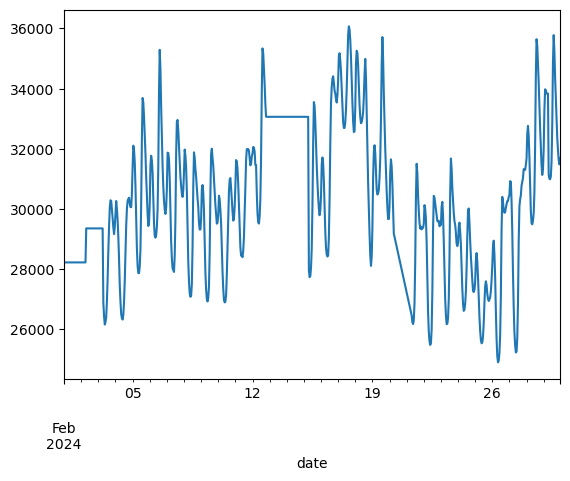

In [26]:
df.loc["2024-02"].Demand.plot()

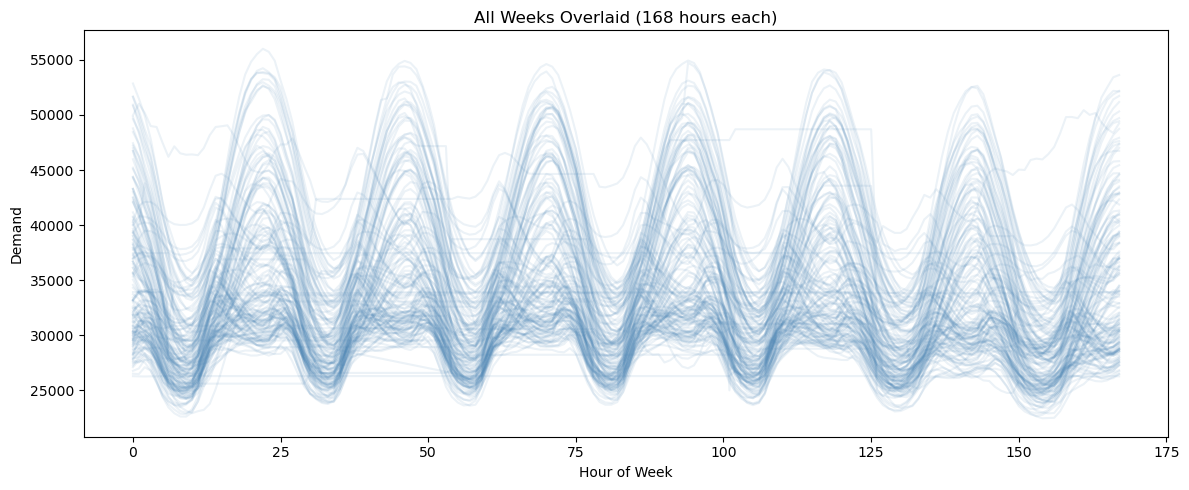

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

for year_week, group in df.groupby([df.index.year, df.index.isocalendar().week]):
    if len(group) == 168:  # full week only
        ax.plot(range(168), group["Demand"].values, alpha=0.1, color="steelblue")

ax.set_title("All Weeks Overlaid (168 hours each)")
ax.set_xlabel("Hour of Week")
ax.set_ylabel("Demand")
plt.tight_layout()
plt.show()

There are some weeks that have flat demand or stretches of flat demand that we will need to deal with. we can select them by looking at the variance across weeks

In [29]:
# Group by year-week, calculate variance and range for each week
weekly_stats = (df
    .groupby([df.index.year, df.index.isocalendar().week])["Demand"]
    .agg(["std", "min", "max", "count"])
    .reset_index()
    .rename(columns={"level_0": "year", "level_1": "week"})
)

weekly_stats["range"] = weekly_stats["max"] - weekly_stats["min"]


In [34]:
#let's look at the variance by week
weekly_stats["std"].describe()

count     156.000000
mean     3614.171084
std      1765.608303
min       741.355265
25%      2106.983307
50%      2777.537798
75%      5171.428605
max      7245.343477
Name: std, dtype: float64

In [30]:
# Sort by lowest variance to find flattest weeks
# if a "typical" week has a std of around 1,700 than anything well below that is worth looking at
suspicious_weeks = weekly_stats.sort_values("std").head(20)
print(suspicious_weeks)

     date  week          std      min      max  count   range
154  2025    51   741.355265  36743.0  42011.0    168  5268.0
61   2024    10  1379.732432  25683.0  32378.0    168  6695.0
112  2025     9  1546.424990  27220.0  35369.0    168  8149.0
103  2024    52  1621.748253  26973.0  33363.0    168  6390.0
63   2024    12  1627.967211  26187.0  31232.0    168  5045.0
56   2024     5  1671.380856  26159.0  36071.0    168  9912.0
45   2023    46  1694.684827  25117.0  31085.0    168  5968.0
57   2024     6  1696.828096  26894.0  35287.0    168  8393.0
99   2024    48  1705.903841  26741.0  35705.0    168  8964.0
117  2025    14  1747.035210  26473.0  32525.0    168  6052.0
8    2023     9  1769.339225  25095.0  32870.0    168  7775.0
62   2024    11  1778.010262  25230.0  32197.0    168  6967.0
148  2025    45  1780.556986  26656.0  32767.0    168  6111.0
46   2023    47  1783.035446  25230.0  33963.0    168  8733.0
48   2023    49  1793.950523  26510.0  35658.0    168  9148.0
114  202

### Drop NAs

In [8]:
#handle the NA values in the demand column fill forward
df.sort_index()
df_clean = df.interpolate(method="linear", limit_direction="forward", axis=0)
df_clean[df_clean.isnull().any(axis = 1)]

,Demand,Temperature,is_day
date,,,


<Axes: xlabel='date'>

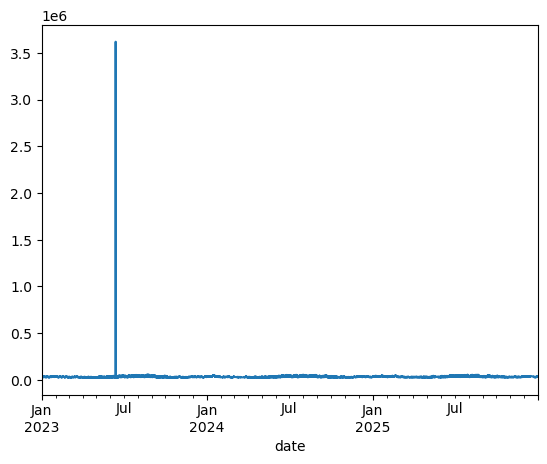

In [11]:
#check for outliers that could skew the data
df_clean.Demand.plot()

In [13]:
df_clean.Demand.describe()

count    2.630400e+04
mean     3.322343e+04
std      2.286381e+04
min      2.245600e+04
25%      2.916300e+04
50%      3.171800e+04
75%      3.579800e+04
max      3.621097e+06
Name: Demand, dtype: float64

In [14]:
df[df["Demand"] == df["Demand"].max()]

,Demand,Temperature,is_day
date,,,
2023-06-13 02:00:00,3621097.0,18.511501,0


In [15]:
#clearly there is an error the the data collection that we need to replace
df_clean["Demand"] = (df_clean["Demand"]
    .mask(df_clean["Demand"] == df_clean["Demand"].max())
    .interpolate(method="time")
)

<Axes: xlabel='date'>

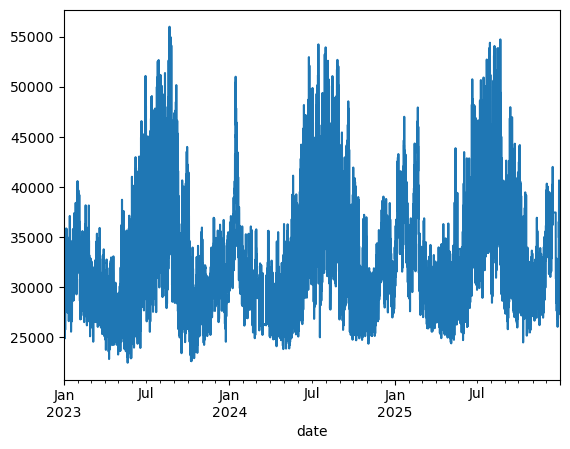

In [16]:
df_clean.Demand.plot()

In [17]:
#let's write the clean df to csv
df_clean.to_csv("../data/raw/loadtempday_clean.csv", index=True)

In [31]:
print(f"start of data: {df.index.min()}")
print(f"end of data: {df.index.max()}")

start of data: 2023-01-01 00:00:00
end of data: 2025-12-31 23:00:00


### Train Val Test Split
- Train: 2023-01-01 to 2024-06-30 (18 months)
- Validation: 2024-07-01 to 2024-12-31 (6 months)
- Test: 2025-01-01 to 2025-12-31 (12 months)

In [18]:
TRAIN_START = "2023-01-01 00:00:00"
#datetime(2023, 1, 1, 0, 0, 0)
TRAIN_END   = "2024-06-30 23:00:00"
#datetime(2024, 6, 30, 23, 0, 0)

VAL_START   = "2024-07-01 00:00:00"
#datetime(2024, 7, 1, 0, 0, 0)
VAL_END     = "2024-12-31 23:00:00"
#datetime(2024, 12, 31, 23, 0, 0)

TEST_START  = "2025-01-01 00:00:00"
#datetime(2025, 1, 1, 0, 0, 0)
TEST_END    = "2025-12-31 23:00:00"
#datetime(2025, 12, 31, 23, 0, 0)

In [19]:
data = df_clean.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Graphs

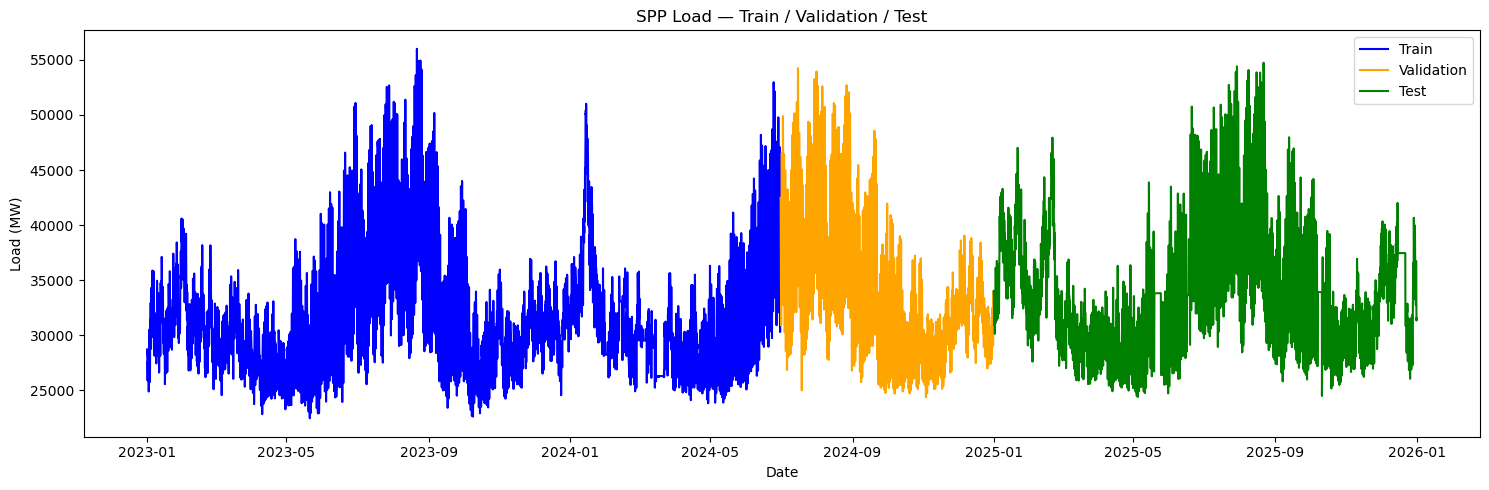

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_train.index, data_train["Demand"], label="Train", color="blue")
ax.plot(data_val.index, data_val["Demand"], label="Validation", color="orange")
ax.plot(data_test.index, data_test["Demand"], label="Test", color="green")

ax.set_title("SPP Load — Train / Validation / Test")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

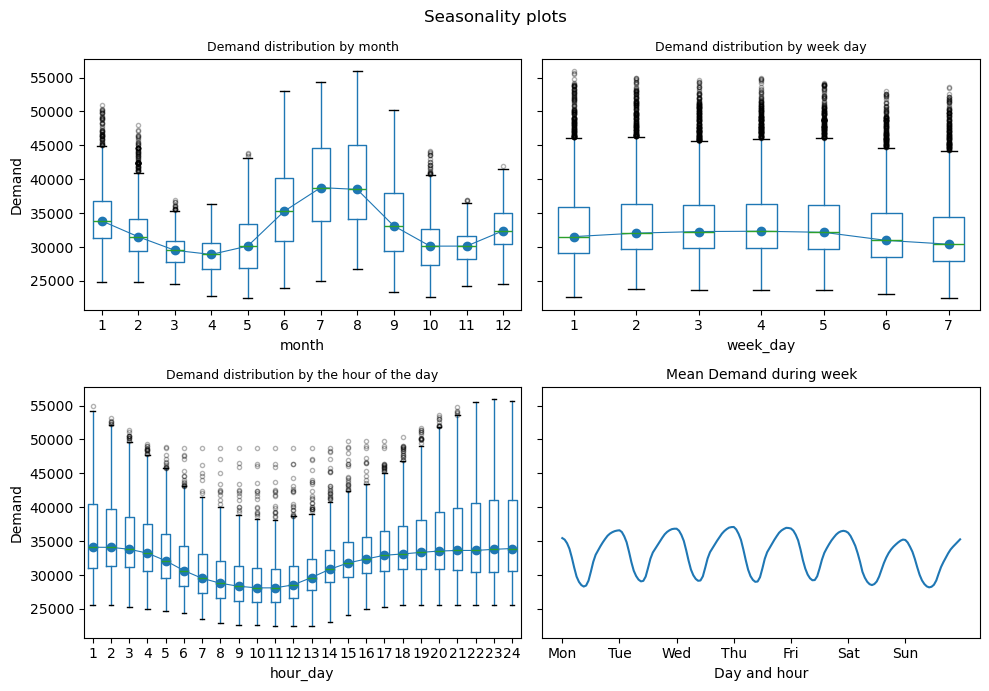

In [22]:
# Annual, weekly and daily seasonality
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=True)
axs = axs.ravel()

# Demand distribution by month
data['month'] = data.index.month
data.boxplot(column='Demand', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('Demand')
axs[0].set_title('Demand distribution by month', fontsize=9)

# Demand distribution by week day
data['week_day'] = data.index.day_of_week + 1
data.boxplot(column='Demand', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('Demand')
axs[1].set_title('Demand distribution by week day', fontsize=9)

# Demand distribution by the hour of the day
data['hour_day'] = data.index.hour + 1
data.boxplot(column='Demand', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
data.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[2])
axs[2].set_ylabel('Demand')
axs[2].set_title('Demand distribution by the hour of the day', fontsize=9)

# Demand distribution by week day and hour of the day
mean_day_hour = data.groupby(["week_day", "hour_day"])["Demand"].mean()
mean_day_hour.plot(ax=axs[3])
axs[3].set(
    title       = "Mean Demand during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day and hour",
    ylabel      = "Number of Demand"
)
axs[3].title.set_size(10)

fig.suptitle("Seasonality plots", fontsize=12)
fig.tight_layout()

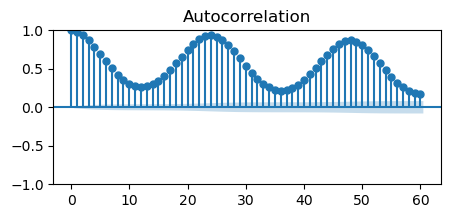

In [25]:
# Autocorrelation plot
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['Demand'], ax=ax, lags=60, fft=True)
plt.show()

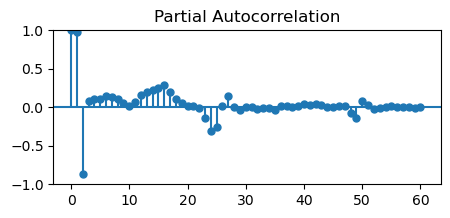

In [26]:
# Partial autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['Demand'], ax=ax, lags=60, method='burg')
plt.show()

In [30]:
# Top 10 lags with the highest absolute partial autocorrelation
# ==============================================================================
calculate_lag_autocorrelation(
    data        = data['Demand'],
    n_lags      = 60,
    sort_by     = "partial_autocorrelation_abs",
    acf_kwargs  = {'fft': True},
    pacf_kwargs = {'method': 'burg'}
).head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.983448,0.983448,0.983433,0.983433
1,2,0.872132,-0.872132,0.938511,0.938511
2,24,0.313445,-0.313445,0.935476,0.935476
3,16,0.285086,0.285086,0.407027,0.407027
4,15,0.254537,0.254537,0.344922,0.344922
5,25,0.253179,-0.253179,0.918148,0.918148
6,14,0.220455,0.220455,0.299811,0.299811
7,17,0.197577,0.197577,0.483329,0.483329
8,13,0.197410,0.197410,0.273051,0.273051
9,12,0.155309,0.155309,0.265431,0.265431
